# Análisis de variables

Distribución clase: {'no': 0.732, 'yes': 0.268}


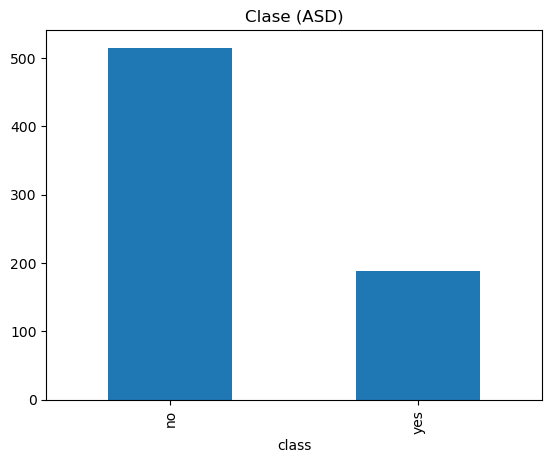

NaN en age: 2


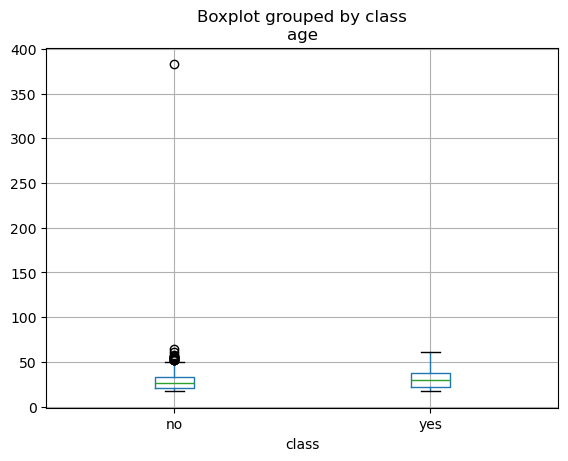


gender vs class:
class      no    yes
gender              
f       0.694  0.306
m       0.766  0.234

jaundice vs class:
class        no    yes
jaundice              
no        0.746  0.254
yes       0.594  0.406

family_pdd vs class:
class          no    yes
family_pdd              
no          0.762  0.238
yes         0.527  0.473

used_app_before vs class:
class               no    yes
used_app_before              
no               0.734  0.266
yes              0.583  0.417

relation vs class:
class                      no    yes
relation                            
healthcareprofessional  0.750  0.250
others                  0.800  0.200
parent                  0.760  0.240
relative                0.679  0.321
self                    0.699  0.301

ethnicity vs class:
class              no    yes
ethnicity                   
asian           0.870  0.130
black           0.581  0.419
hispanic        0.615  0.385
latino          0.500  0.500
middleeastern   0.913  0.087
others        

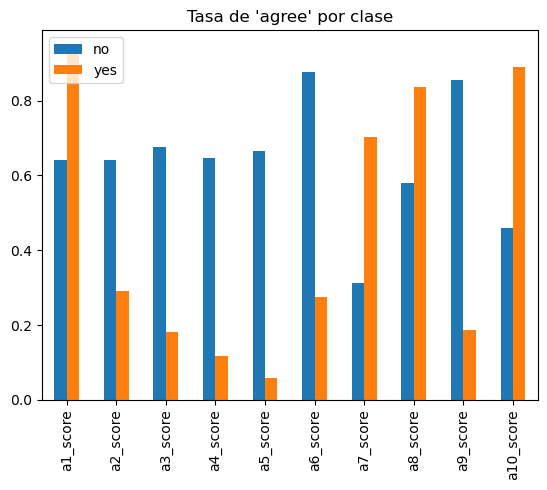

In [1]:
import sys; sys.path.insert(0, "..")
import pandas as pd, matplotlib.pyplot as plt
from functions_scripts.load import read_data
from classes.Preparador3 import Preparador3

df = Preparador3().preparar(read_data(filepath="../data/Autism-Adult-Data.csv"))

# 1) Desbalanceo de la clase
print("Distribución clase:", df["class"].value_counts(normalize=True).round(3).to_dict())
df["class"].value_counts().plot(kind="bar", title="Clase (ASD)"); plt.show()

# 2) Valores perdidos
for col in df.select_dtypes(include="category").columns:
    n = (df[col] == "?").sum()
    if n: print(f"'?' en {col}: {n}")
print("NaN en age:", df["age"].isna().sum())

# 3) age vs clase
df.boxplot(column="age", by="class"); plt.show()

# 4) Categóricas vs clase
for col in ["gender", "jaundice", "family_pdd", "used_app_before", "relation", "ethnicity"]:
    print(f"\n{col} vs class:")
    print(pd.crosstab(df[col], df["class"], normalize="index").round(3))

# 5) Scores A1..A10 vs clase
scores = [f"a{i}_score" for i in range(1, 11)]
tasa = pd.DataFrame({c: (df.loc[df["class"]==c, scores]=="agree").mean() for c in df["class"].cat.categories})
tasa.plot(kind="bar", title="Tasa de 'agree' por clase"); plt.show()